# Chapter 9: Machine Learning Intro 1

In [1]:
import matplotlib.image as img
import matplotlib.pyplot as plt

import copy
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from os import listdir
from sklearn.model_selection import train_test_split
import seaborn as sns; sns.set()
from sklearn import metrics

## 9.1 Introduction

By now we have seen how to load in data, how to analyse it and modify it to fit our needs. Great! But what exactly are we going to do with this? The most common goals is to create machine learning models to try and make some interesting predictions based on our data. By doing so, we can solve real-world problems and hopefully make our bosses happy :D

But first, let's take a step back. What exactly is machine learning? Well, in a world dominated by ai chatbots such as chatGPT, grok and deepseek, it's easy to label everything as "AI". In a way this is not wrong, but it is however too generic. Machine learning is a specific subset of AI, where the focus lies on gathering a bunch of data, cleaning and preparing this data (which you should be able to do by now), feeding it to an algorithm and tweaking it untill you are happy with the results. In other words, it's the little brother of chatGPT that you constantly have to babysit, but is a lot of fun to hang out with.

While there are many different machine learning models out there, each with their own nuances, we will not be diving into the specifics of those. That's for next year, during your classes of Machine Learning and Data Science Fundamentals. Instead, we will be looking at exactly how we can use the data we have prepared so far to train a machine learning model, how we can improve it even further and already dipping our toes a little bit into evaluating the results!

## 9.2 The Flower Dataset

Today we will be working with the flower dataset. This is a dataset containing, you guessed it, flowers! Each flower is noted with some measurements of the leaves, as well as the name of the flower. Load in the data and have a look.

In [19]:
iris = pd.read_csv('iris_data.csv')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### Question 1: based off this data, what kind of information might we aim to predict or discover using Machine Learning models?

To start, each column might be an interesting variable to try and predict when a new flower comes in. The obvious first choice here is the "species" column, as it shows exactly what kind of flower we have. Trying to predict this based on the measurements of the leaves is a typical example of **classification**. The remaining columns can also be interesting to predict. Say we have found half a leaf of a setoa, based on the width of the leaf and the type of flower, we might be able to predict exactly how long the leaf was. This is a typical example of **regression**.

There are also other interesting things we might try to discover. Maybe we are able to discover some patterns in the data that we have not found before. By throwing the data in a model and asking it to group similar flowers together, we might find some groups of sub species. Even though we will not get a name for this, by knowing they are very similar we can investigate it further. This is a clear example of **clustering**.

### Question 2: Let's have a first look at the data. How can we gain insights from our dataset? What can we learn from this?

In [21]:
iris.shape

(150, 5)

We can see that we have 150 flower records, and 5 columns containing data.

In [23]:
iris.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

All of our columns are floats, except for the 'species' column, which is an object. This is to be expected, as that column contains the name of our flower, also know as the "label" in machine learning.

We can also note that since the other columns are floats, as expected since we know they contain measurements, there likely won't be any missing values in there. If there were, the column data types would not be floats.

In [22]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


We can confirm that there are no missing values, as the count is 150 across all columns. There are also no strange (zero, negative or abnormally high) values as the minimum or maximum values.

## 9.3 Our first ML model

Now it's time to dive into mzchine learning and create our first model! Again, we will not be diving into the specifics of which model to choose and how it works exactly as you will be doing that plenty of times next year (but feel free to do some own research already!), so for now just follow along.

Creating a model in python is actually really easy, all it takes is just a single line of code:

In [24]:
ML_model = RandomForestClassifier()
ML_model

RandomForestClassifier()

While we have created our model, it has not yet fitted the data which means it hasn't learned anything yet. This is logical, as we haven't given it any data yet. To do so, we need two things:

1) X, which is the raw dataset which it can use to learn the appropriate patterns
2) Y, the outcome vector (the labels it should try to learn)

### Question 3: It is extremely important to make sure that the outcome vector Y is not in X. Can you think why this is?

if we include Y in our X, the model will use Y to predict Y. Of course, this means it will not learn anything from the data and just repeat what is in the Y column. It's the same as trying to guess the age of a person, when they are wearing a hat with their age on it. You don't have to look at the person itself, you just read what's on the hat. This is called a **data leak** for obvious reasons.

### Question 4: Prepare the X and Y variables. The X subset should contain 'sepal_length', 'sepal_width', 'petal_length' and 'petal_width' while the Y variable should only contain 'species'.

In [25]:
X = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
Y = iris['species']

Once you have prepared the data, train your model.

In [26]:
ML_model.fit(X, Y)
ML_model

RandomForestClassifier()

Nothing seems to have changed, however we did fit this model to the data so now it should work. Let's try it out by giving it some data. Let's first make a fake flower and see if we can have the model predict this fake flower, just to see if the model does something (i.e. provide a label given some flower input variables)

In [27]:
fake_flower = pd.DataFrame({'sepal_length': 5, 
                               'sepal_width' :3,
                               'petal_length' : 1,
                               'petal_width': 0.5}, index = [0])
                           
fake_flower                          

,sepal_length,sepal_width,petal_length,petal_width
0,5,3,1,0.5


In [28]:
ML_model.predict(fake_flower)

array(['setosa'], dtype=object)

Allright, it seems the model is working. We can get a label back from some fake flower we created. Now we can maybe check if the model has learned correctly by giving it the original data. Then we can see what output it gives and we can compare that easily with the true labels we know.

In [45]:
y_pred = ML_model.predict(X)

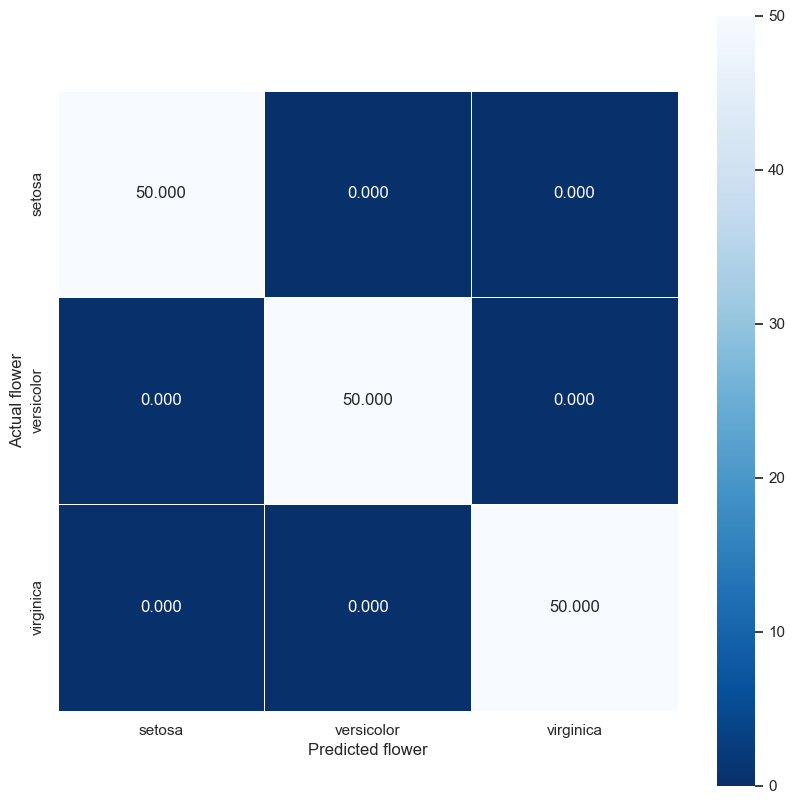

In [46]:
labels = ['setosa', 'versicolor', 'virginica']
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(Y, y_pred, labels=labels),
            annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r',
            xticklabels=labels, yticklabels=labels);
plt.ylabel('Actual flower');
plt.xlabel('Predicted flower');

### Question 5: How can we interpret the matrix above? Do you notice anything suspicious? Can you explain it?

Wow amazing, the model has clearly learned what the differenc is between all the flowers. Because it is always correct.

Now some of you with good spider senses will probably start thinking that something is wrong. How can it make not a single mistake. Surely the problem is not that easy.

And you are right, we are indeed making a grave mistake. We are testing a model on data it is also trained on. That's like taking a test with the eaxct same questions as the exercise during class. Of course you know the answers, but does that mean you know the entire subject?

We can check this by making a so called **train-test split**. Before we start we will divide our data in 2 parts, one part used for training the model (the training set), and one part for testing the model afterwards (the test set). 

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.25) 

In [51]:
X_train.shape

(112, 4)

In [52]:
X_test.shape

(38, 4)

### Question 6: Based on the values above, what does the test_size parameter do?

Our X_train dataset contains 112 records (about 75% of our original dataset), while our X_test dataset contains 38 records (about 25% of our original dataset). This means that the test_size parameter decided how much data we want to keep aside for testing. Ususally, a value between 20%-30% is picked.

As we can see the train_test_split function has given us a number of things:

1) training data (X_train)
2) training outcome to predict (y_train)
3) test data (X_test)
4) test outcome to predict (y_test)

Let's fit the model again on the training data. To do so, let's create a new empty model first.

In [53]:
ML_model = RandomForestClassifier()
ML_model

ML_model.fit(X_train, y_train)

RandomForestClassifier()

Now let's evaluate it. Let's check the train data first. We suspect that this will be good since it has used this data for learning.

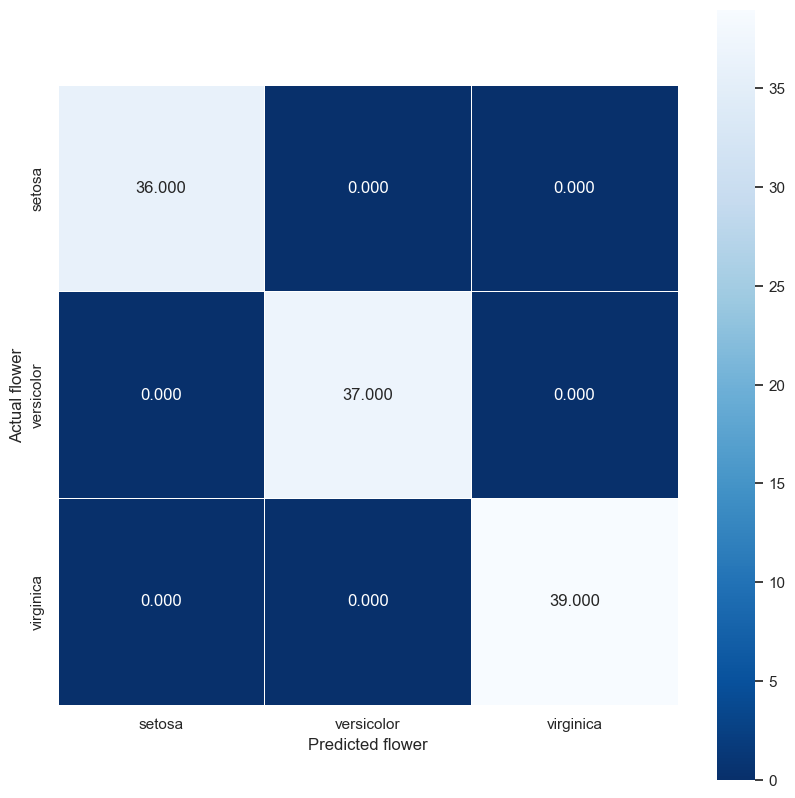

In [55]:
y_pred = ML_model.predict(X_train)

labels = ['setosa', 'versicolor', 'virginica']
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(y_train, y_pred, labels=labels),
            annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r',
            xticklabels=labels, yticklabels=labels);
plt.ylabel('Actual flower');
plt.xlabel('Predicted flower');

As expected, no faults. But now for the unseen test data:

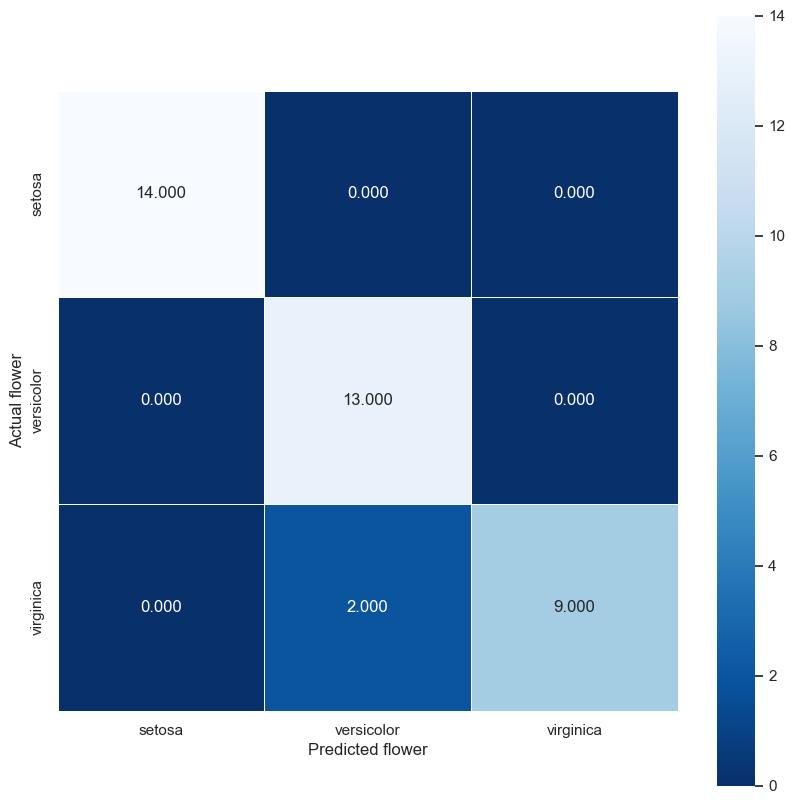

In [56]:
y_pred = ML_model.predict(X_test)

labels = ['setosa', 'versicolor', 'virginica']
plt.figure(figsize=(10,10))
sns.heatmap(metrics.confusion_matrix(y_test, y_pred, labels=labels),
            annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r',
            xticklabels=labels, yticklabels=labels);
plt.ylabel('Actual flower');
plt.xlabel('Predicted flower');

### Question 7: What has changed? What does this mean?

The results on the unseen data are not perfect, as 2 versicolor flowers receive a 'virginica' prediction, but very good results nonetheless. It must be that the problem is rather easy for this machine learning model.